In [1]:
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import rasterio.transform
import pyproj
import pyarrow as pa
import pyarrow.parquet as pq
from simplification.cutil import simplify_coords_vw

In [2]:
with rasterio.open("../data/gully-pass3/Dutch Bill Creek-pass3-graph.tif") as file:
    graph = file.read(1)
    index_to_crs = file.transform
    crs_to_lonlat = pyproj.Transformer.from_crs(file.crs, "EPSG:4326", always_xy=True)
    def index_to_lonlat(i, j):
        return crs_to_lonlat.transform(*rasterio.transform.xy(index_to_crs, i, j))

In [3]:
# bitmasks for 8-connected neighborhood directions
connected_NW = np.uint8(0b00000001)
connected_N  = np.uint8(0b00000010)
connected_NE = np.uint8(0b00000100)
connected_W  = np.uint8(0b00001000)
connected_E  = np.uint8(0b00010000)
connected_SW = np.uint8(0b00100000)
connected_S  = np.uint8(0b01000000)
connected_SE = np.uint8(0b10000000)

In [4]:
def possible_steps(i1, j1, i2, j2):
    out = []
    if graph[i2, j2] & connected_NW:
        i3, j3 = i2 - 1, j2 - 1
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_N:
        i3, j3 = i2 - 1, j2
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_NE:
        i3, j3 = i2 - 1, j2 + 1
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_W:
        i3, j3 = i2, j2 - 1
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_E:
        i3, j3 = i2, j2 + 1
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_SW:
        i3, j3 = i2 + 1, j2 - 1
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_S:
        i3, j3 = i2 + 1, j2
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    if graph[i2, j2] & connected_SE:
        i3, j3 = i2 + 1, j2 + 1
        if (i3, j3) != (i1, j1):
            out.append((i3, j3))
    return out

In [5]:
def only_step(pair1, pair2):
    i1, j1 = pair1
    i2, j2 = pair2
    out = []
    if graph[i2, j2] & connected_NW:
        i3, j3 = i2 - 1, j2 - 1
        if (i3, j3) != (i1, j1):
            return (i3, j3)
    if graph[i2, j2] & connected_N:
        i3, j3 = i2 - 1, j2
        if (i3, j3) != (i1, j1):
            return (i3, j3)
    if graph[i2, j2] & connected_NE:
        i3, j3 = i2 - 1, j2 + 1
        if (i3, j3) != (i1, j1):
            return (i3, j3)
    if graph[i2, j2] & connected_W:
        i3, j3 = i2, j2 - 1
        if (i3, j3) != (i1, j1):
            return (i3, j3)
    if graph[i2, j2] & connected_E:
        i3, j3 = i2, j2 + 1
        if (i3, j3) != (i1, j1):
            return (i3, j3)
    if graph[i2, j2] & connected_SW:
        i3, j3 = i2 + 1, j2 - 1
        if (i3, j3) != (i1, j1):
            return (i3, j3)
    if graph[i2, j2] & connected_S:
        i3, j3 = i2 + 1, j2
        if (i3, j3) != (i1, j1):
            return (i3, j3)
    if graph[i2, j2] & connected_SE:
        i3, j3 = i2 + 1, j2 + 1
        if (i3, j3) != (i1, j1):
            return (i3, j3)
    return out

In [6]:
def is_linear(pair):
    i, j = pair
    return num_connections[i, j] == 2

In [7]:
num_connections = np.unpackbits(graph).reshape(graph.shape + (8,)).sum(axis=-1)

In [8]:
path_seeds = np.concatenate([
    np.dstack(np.nonzero(num_connections == 1))[0],
    np.dstack(np.nonzero(num_connections >= 3))[0],
], axis=0)

In [9]:
%%time

paths = []
for i1, j1 in path_seeds:
    seen = set()
    for i2, j2 in possible_steps(i1, j1, i1, j1):
        for i3, j3 in possible_steps(i1, j1, i2, j2):
            if (i3, j3) not in seen:
                seen.add((i3, j3))
                path = [(i1, j1), (i2, j2), (i3, j3)]
                while is_linear(path[-1]):
                    path.append(only_step(path[-2], path[-1]))
                paths.append(path)

CPU times: user 739 ms, sys: 28 ms, total: 767 ms
Wall time: 766 ms


In [10]:
cmap = mpl.colors.LinearSegmentedColormap.from_list("white_magenta", ["white", "magenta"])

In [11]:
darker = (
    graph[0:4000, 0:4000] |
    graph[0:4000, 1:4001] |
    graph[0:4000, 2:4002] |
    graph[1:4001, 0:4000] |
    graph[1:4001, 1:4001] |
    graph[1:4001, 2:4002] |
    graph[2:4002, 0:4000] |
    graph[2:4002, 1:4001] |
    graph[2:4002, 2:4002] != 0
)

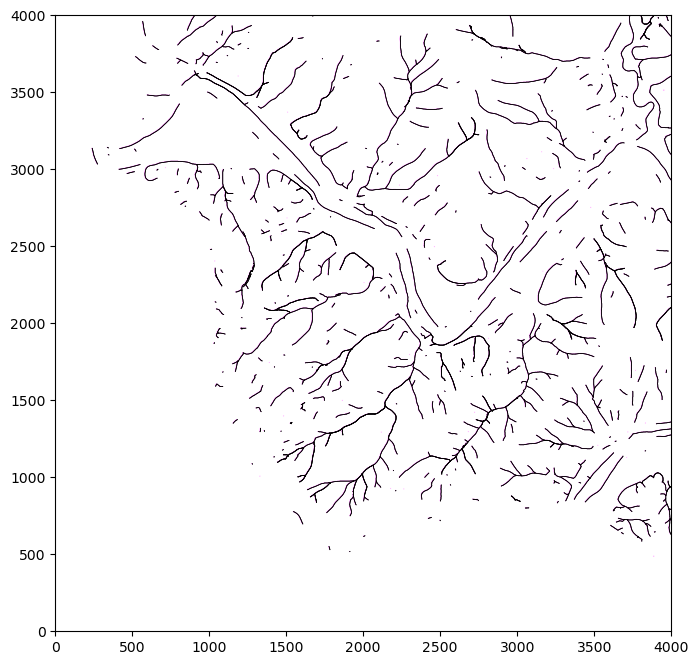

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(darker, vmin=0, vmax=1, cmap=cmap)

for path in paths:
    ax.plot([j for i, j in path], [i for i, j in path], linewidth=0.5, c="black")

ax.set_xlim(0, 4000)
ax.set_ylim(0, 4000)

None

In [13]:
matches_by_midpoint = {}
for path in paths:
    for pair in path:
        if is_linear(pair):
            if pair not in matches_by_midpoint:
                matches_by_midpoint[pair] = []
            matches_by_midpoint[pair].append(path)

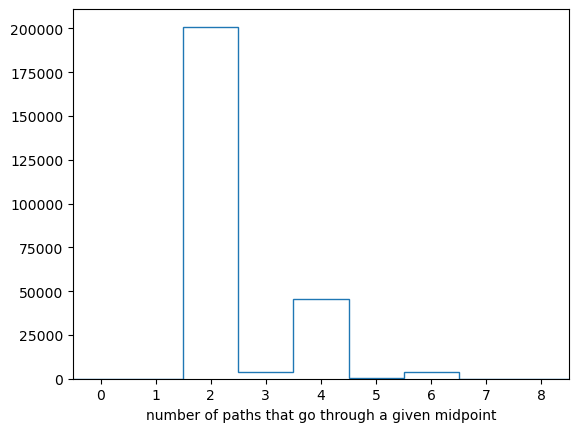

In [14]:
fig, ax = plt.subplots()

ax.hist([len(matches) for matches in matches_by_midpoint.values()], bins=9, range=(-0.5, 8.5), histtype="step")

ax.set_xlabel("number of paths that go through a given midpoint")
ax.set_xticks(range(9))
ax.set_xlim(-0.5, 8.5)

None

In [15]:
longest_by_midpoint = {}
for midpoint, matches in matches_by_midpoint.items():
    longest_by_midpoint[midpoint] = sorted(matches, key=len)[-1]

In [16]:
unique_paths = sorted(set(tuple(match) for match in longest_by_midpoint.values()), key=len, reverse=True)

In [17]:
len(unique_paths), len(paths)

(3735, 10284)

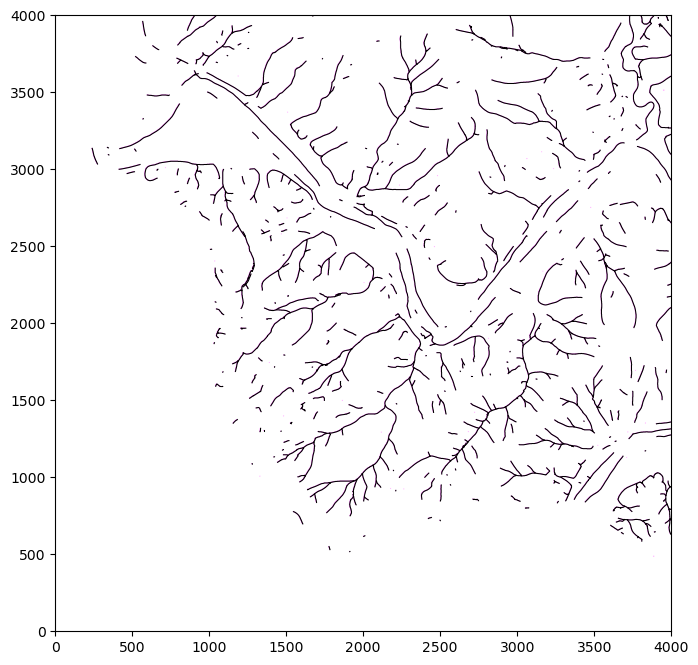

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(darker, vmin=0, vmax=1, cmap=cmap)

for path in unique_paths:
    ax.plot([j for i, j in path], [i for i, j in path], linewidth=0.75, c="black")

ax.set_xlim(0, 4000)
ax.set_ylim(0, 4000)

None

In [49]:
simplified_paths = [simplify_coords_vw(path, 10.0) for path in unique_paths]

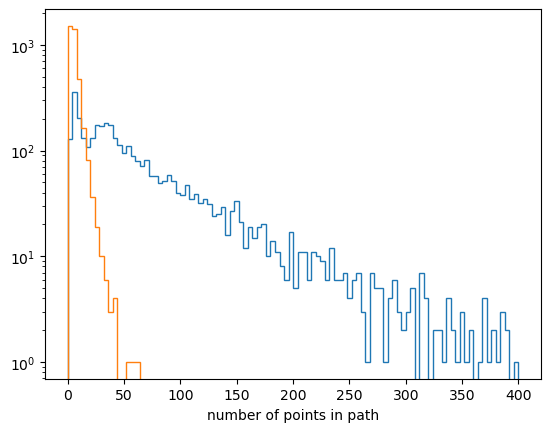

In [50]:
fig, ax = plt.subplots()

ax.hist([len(path) for path in unique_paths], bins=100, range=(0, 400), histtype="step", label="original paths")
ax.hist([len(path) for path in simplified_paths], bins=100, range=(0, 400), histtype="step", label="simplified paths")

ax.set_yscale("log")
ax.set_xlabel("number of points in path")

None

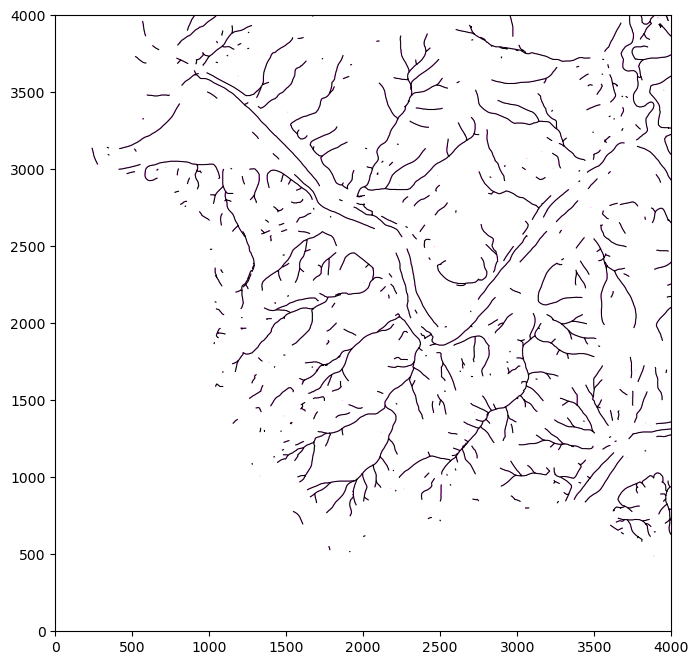

In [51]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(darker, vmin=0, vmax=1, cmap=cmap)

for path in simplified_paths:
    ax.plot([j for i, j in path], [i for i, j in path], linewidth=0.75, c="black")

ax.set_xlim(0, 4000)
ax.set_ylim(0, 4000)

None

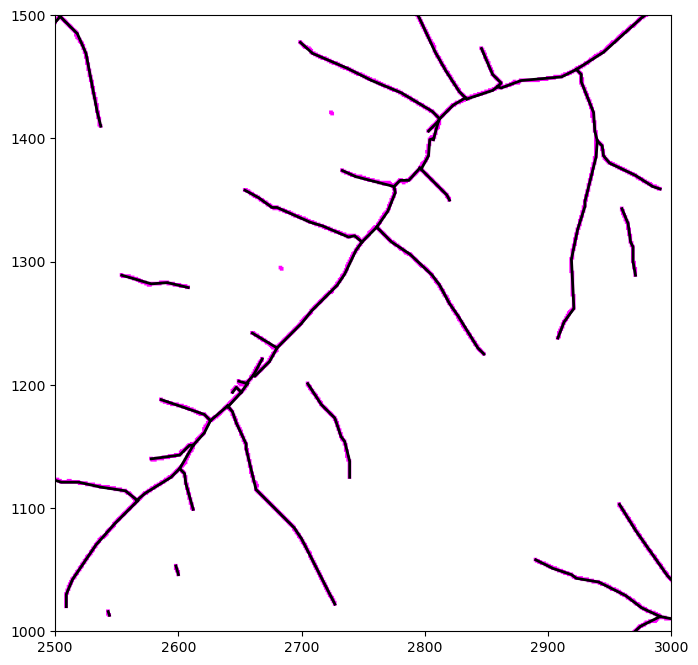

In [52]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(darker, vmin=0, vmax=1, cmap=cmap)

for path in simplified_paths:
    ax.plot([j - 1 for i, j in path], [i - 1 for i, j in path], linewidth=2, c="black")

ax.set_xlim(2500, 3000)
ax.set_ylim(1000, 1500)

None

In [53]:
endpoints = {}
junction_count = Counter()

def get_approximate_endpoint(pair, endpoints):
    i, j = pair
    for di, dj in [
        (0, 0),
        (0, -1),
        (0, 1),
        (-1, 0),
        (1, 0),
        (-1, -1),
        (-1, 1),
        (1, -1),
        (1, 1),
    ]:
        endpoint_id = endpoints.get((i + di, j + dj))
        if endpoint_id is not None:
            return endpoint_id

    endpoint_id = len(endpoints)
    endpoints[(i, j)] = endpoint_id
    return endpoint_id

simplified_paths_starts = []
simplified_paths_stops = []
for path in simplified_paths:
    start = get_approximate_endpoint(path[0], endpoints)
    stop = get_approximate_endpoint(path[-1], endpoints)
    simplified_paths_starts.append(start)
    simplified_paths_stops.append(stop)
    junction_count[start] += 1
    junction_count[stop] += 1

In [54]:
len(endpoints), len(junction_count), len(simplified_paths)

(5127, 5127, 3735)

In [55]:
endpoints_lon = pa.array([[index_to_lonlat(i, j)[0] for i, j in endpoints.keys()]])
endpoints_lat = pa.array([[index_to_lonlat(i, j)[1] for i, j in endpoints.keys()]])

In [56]:
endpoints_junction_count = pa.array([[junction_count[endpoint_id] for endpoint_id in endpoints.values()]])

In [57]:
len(endpoints_lon[0]), len(endpoints_lat[0]), len(endpoints_junction_count[0])

(5127, 5127, 5127)

In [58]:
paths_lon = pa.array([[[index_to_lonlat(i, j)[0] for i, j in path] for path in simplified_paths]])
paths_lat = pa.array([[[index_to_lonlat(i, j)[1] for i, j in path] for path in simplified_paths]])

In [59]:
paths_start_endpoint_id = pa.array([simplified_paths_starts])
paths_stop_endpoint_id = pa.array([simplified_paths_stops])

In [60]:
len(paths_lon[0]), len(paths_lat[0]), len(paths_start_endpoint_id[0]), len(paths_stop_endpoint_id[0])

(3735, 3735, 3735, 3735)

In [61]:
pq.write_table(
    pa.Table.from_arrays(
        [endpoints_lon, endpoints_lat, endpoints_junction_count, paths_lon, paths_lat, paths_start_endpoint_id, paths_stop_endpoint_id],
        ["endpoints_lon", "endpoints_lat", "endpoints_junction_count", "paths_lon", "paths_lat", "paths_start_endpoint_id", "paths_stop_endpoint_id"],
    ),
    "/tmp/test.parquet",
    compression="snappy",
    write_statistics=True,
)